# 01 - Exploratory Data Analysis
**Project:** Credit Card Default Prediction  
**Dataset:** UCI Default of Credit Card Clients 

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YinzhiZZZ/MLBA_credit-default-prediction/blob/main/notebooks/01_EDA.ipynb)

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [16]:
# ── Load Data ─────────────────────────────────────────────────────────────────
# Change to 'UCI_Credit_Card.csv' if using Google Colab
DATA_PATH = '../data/UCI_Credit_Card.csv'

df = pd.read_csv(DATA_PATH)

# Rename last column to 'default'
df.columns = list(df.columns[:-1]) + ['default']

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [17]:
print(df.columns.tolist())

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default']


In [18]:
# ── Basic Info ────────────────────────────────────────────────────────────────
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Summary Statistics ===')
df.describe().T

=== Data Types ===
ID             int64
LIMIT_BAL    float64
SEX            int64
EDUCATION      int64
MARRIAGE       int64
AGE            int64
PAY_0          int64
PAY_2          int64
PAY_3          int64
PAY_4          int64
PAY_5          int64
PAY_6          int64
BILL_AMT1    float64
BILL_AMT2    float64
BILL_AMT3    float64
BILL_AMT4    float64
BILL_AMT5    float64
BILL_AMT6    float64
PAY_AMT1     float64
PAY_AMT2     float64
PAY_AMT3     float64
PAY_AMT4     float64
PAY_AMT5     float64
PAY_AMT6     float64
default        int64
dtype: object

=== Missing Values ===
ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
default      0
dtype: int64

=== Summary Statistics ===


,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


=== Target Distribution ===
         Count  Percentage (%)
default                       
0        23364           77.88
1         6636           22.12


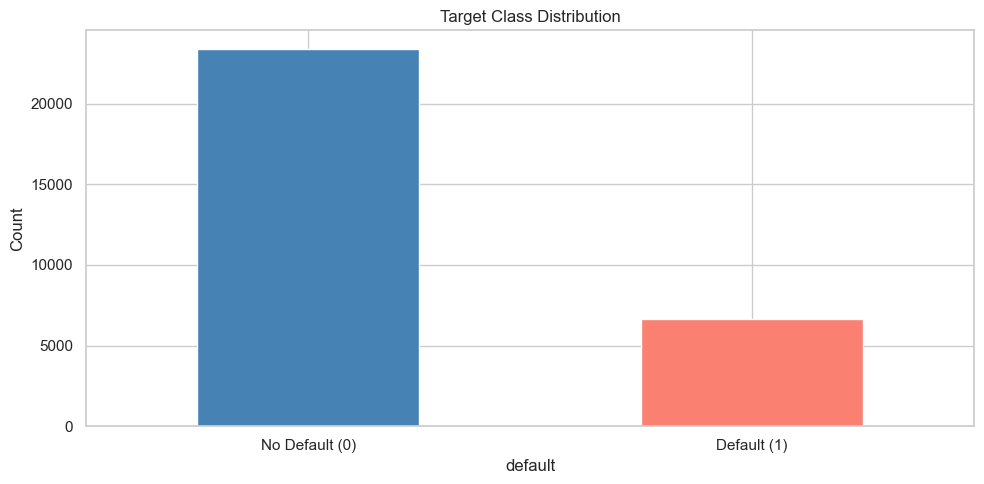


Note: ~22% default rate means the dataset is imbalanced.
Accuracy alone will be misleading — we will prioritize AUC-ROC and Recall.


In [19]:
# ── Class Distribution ────────────────────────────────────────────────────────
# Check target imbalance: 0 = No default, 1 = Default
default_counts = df['default'].value_counts()
default_pct = df['default'].value_counts(normalize=True) * 100

print('=== Target Distribution ===')
print(pd.DataFrame({'Count': default_counts, 'Percentage (%)': default_pct.round(2)}))

fig, ax = plt.subplots()
default_counts.plot(kind='bar', color=['steelblue', 'salmon'], ax=ax)
ax.set_title('Target Class Distribution')
ax.set_xticklabels(['No Default (0)', 'Default (1)'], rotation=0)
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

print('\nNote: ~22% default rate means the dataset is imbalanced.')
print('Accuracy alone will be misleading — we will prioritize AUC-ROC and Recall.')

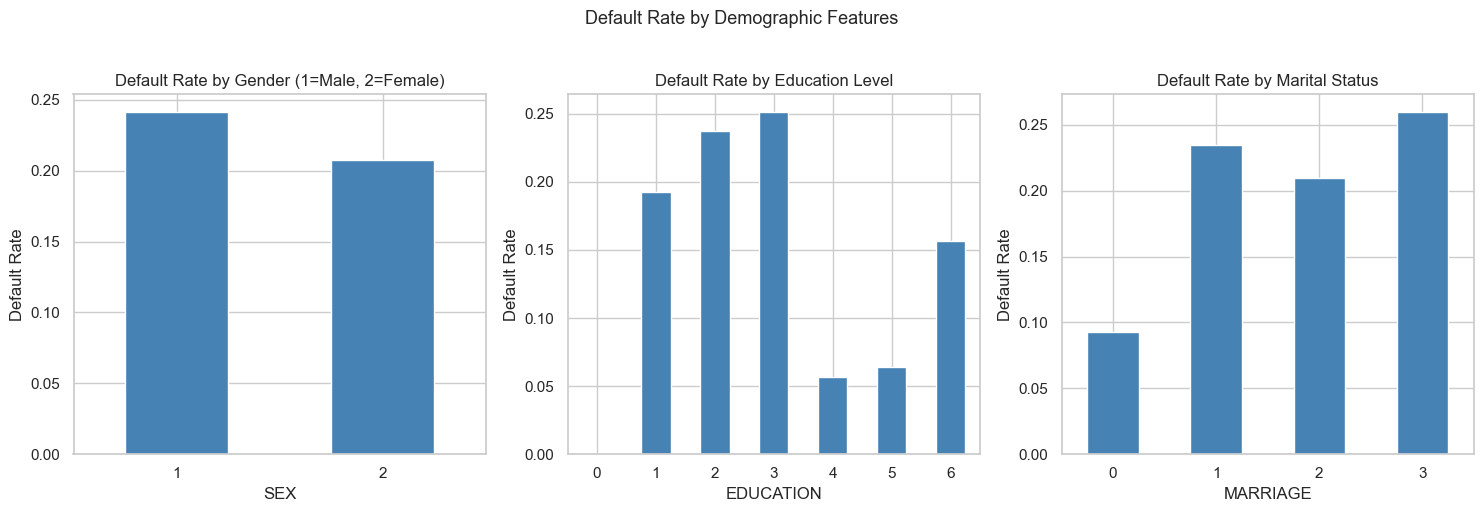

In [20]:
# ── Default Rate by Demographic Features ──────────────────────────────────────
# SEX: 1=Male, 2=Female
# EDUCATION: 1=Graduate school, 2=University, 3=High school, 4=Others
# MARRIAGE: 1=Married, 2=Single, 3=Others

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, title in zip(axes,
                           ['SEX', 'EDUCATION', 'MARRIAGE'],
                           ['Gender (1=Male, 2=Female)', 'Education Level', 'Marital Status']):
    df.groupby(col)['default'].mean().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'Default Rate by {title}')
    ax.set_ylabel('Default Rate')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.suptitle('Default Rate by Demographic Features', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

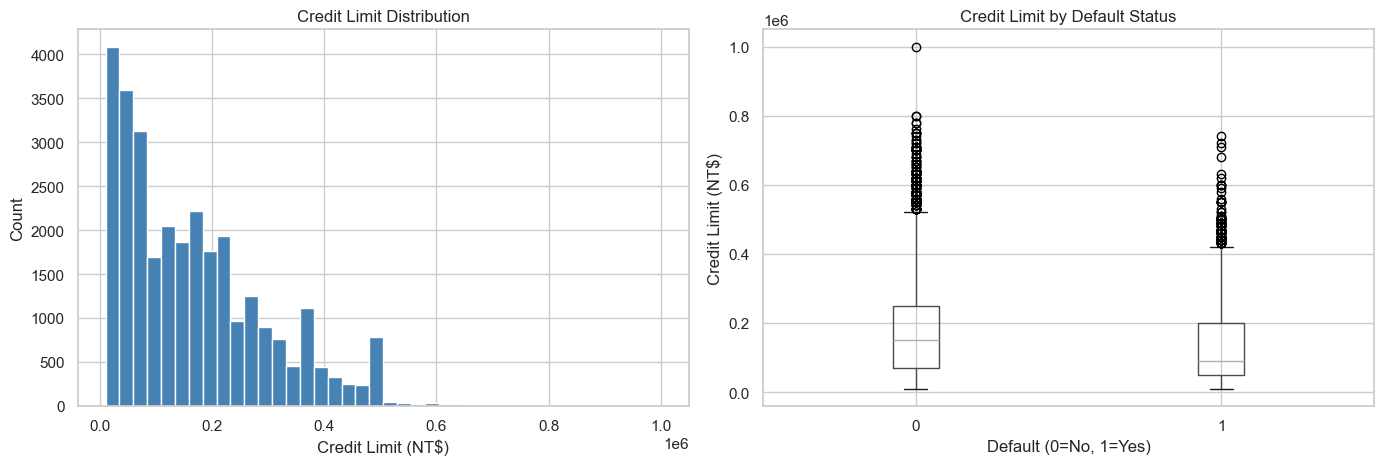

Observation: Customers who defaulted tend to have lower credit limits.


In [21]:
# ── Credit Limit vs Default ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of credit limit
axes[0].hist(df['LIMIT_BAL'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Credit Limit Distribution')
axes[0].set_xlabel('Credit Limit (NT$)')
axes[0].set_ylabel('Count')

# Credit limit by default status
df.boxplot(column='LIMIT_BAL', by='default', ax=axes[1])
axes[1].set_title('Credit Limit by Default Status')
axes[1].set_xlabel('Default (0=No, 1=Yes)')
axes[1].set_ylabel('Credit Limit (NT$)')
plt.suptitle('')

plt.tight_layout()
plt.show()

print('Observation: Customers who defaulted tend to have lower credit limits.')

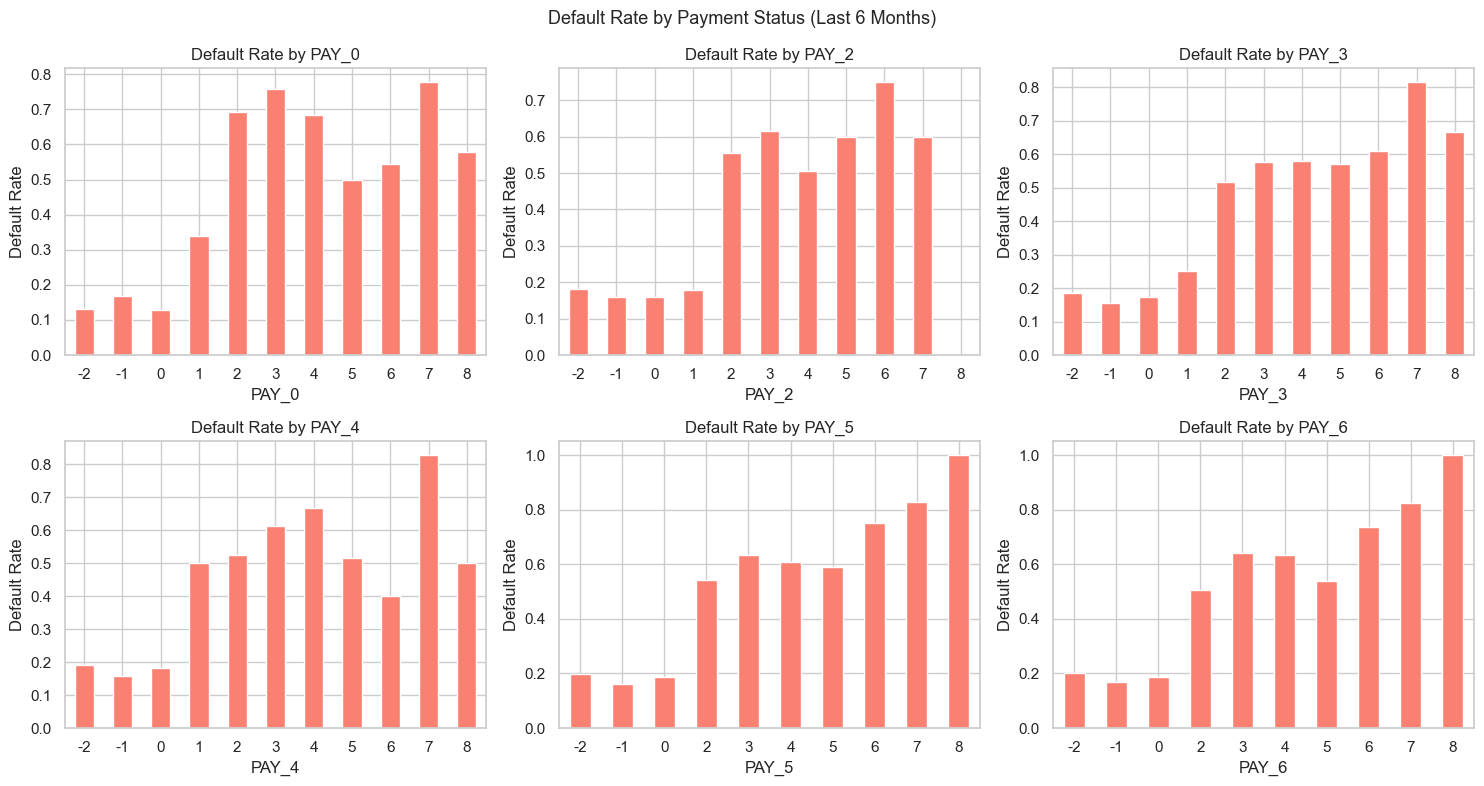

Observation: Higher payment delay codes strongly correlate with default.


In [22]:
# ── Payment Status Features (PAY_0 to PAY_6) ─────────────────────────────────
# PAY_0 = repayment status in September 2005 (most recent)
# Values: -1=pay duly, 1=1 month delay, 2=2 months delay, etc.
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, pay_cols):
    df.groupby(col)['default'].mean().plot(kind='bar', ax=ax, color='salmon')
    ax.set_title(f'Default Rate by {col}')
    ax.set_ylabel('Default Rate')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.suptitle('Default Rate by Payment Status (Last 6 Months)', fontsize=13)
plt.tight_layout()
plt.show()

print('Observation: Higher payment delay codes strongly correlate with default.')

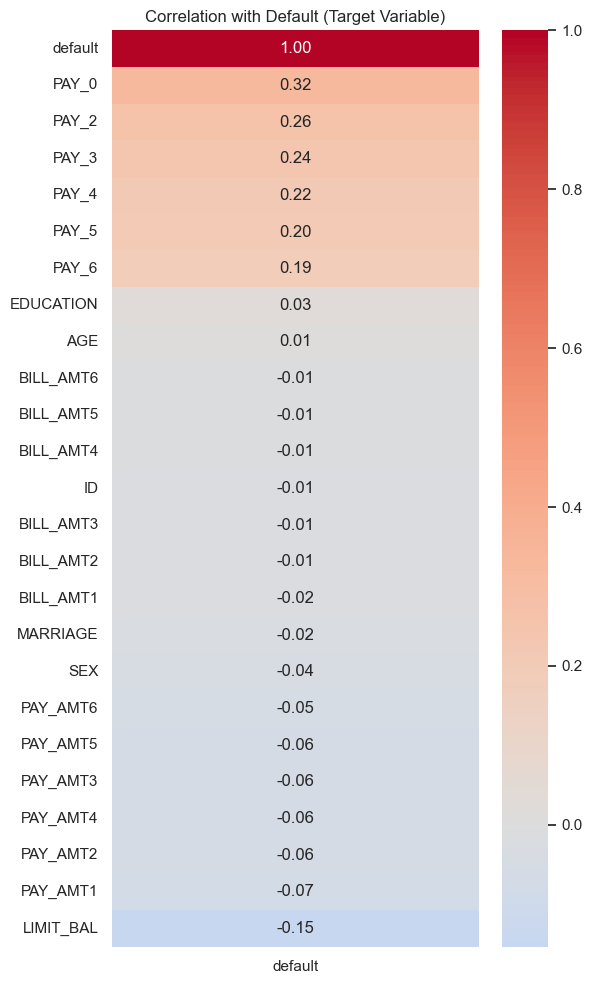

In [23]:
# ── Correlation Heatmap ───────────────────────────────────────────────────────
# Focus on correlation between numeric features and the target
corr = df.corr()[['default']].sort_values('default', ascending=False)

plt.figure(figsize=(6, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation with Default (Target Variable)')
plt.tight_layout()
plt.show()

In [24]:
# ── Key Takeaways ─────────────────────────────────────────────────────────────
print('=== EDA Summary ===')
print('1. Dataset has no missing values — no imputation needed.')
print('2. Target is imbalanced (~22% default) — use AUC-ROC and Recall as primary metrics.')
print('3. Payment status features (PAY_0 to PAY_6) are the strongest predictors of default.')
print('4. Lower credit limits are associated with higher default risk.')
print('5. Demographic features (gender, education, marital status) show minor differences in default rate.')

=== EDA Summary ===
1. Dataset has no missing values — no imputation needed.
2. Target is imbalanced (~22% default) — use AUC-ROC and Recall as primary metrics.
3. Payment status features (PAY_0 to PAY_6) are the strongest predictors of default.
4. Lower credit limits are associated with higher default risk.
5. Demographic features (gender, education, marital status) show minor differences in default rate.
